In [1]:
library(tidyverse)
library(devtools) 
if (basename(getwd()) != "dieseoR") setwd("dieseoR")
load_all()
source("~/workspace/local.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: usethis

ℹ Loading dieseoR


In [2]:
all_tickets <- clean_master(file.path(datadir, "zendesk/all_tickets.rds"))

In [3]:
str(all_tickets)

'data.frame':	109674 obs. of  48 variables:
 $ url                      : chr  "https://pummys.zendesk.com/api/v2/tickets/187457.json" "https://pummys.zendesk.com/api/v2/tickets/195862.json" "https://pummys.zendesk.com/api/v2/tickets/197083.json" "https://pummys.zendesk.com/api/v2/tickets/205771.json" ...
 $ id                       : int  187457 195862 197083 205771 467766 468048 468849 469202 470011 471062 ...
 $ external_id              : logi  NA NA NA NA NA NA ...
 $ created_at               : chr  "2023-10-26t02:24:57z" "2023-11-13t11:39:11z" "2023-11-14t20:53:49z" "2023-12-07t11:49:59z" ...
 $ updated_at               : chr  "2025-11-28t10:21:12z" "2025-11-28t11:25:50z" "2025-11-28t11:25:50z" "2025-11-28t11:25:50z" ...
 $ generated_timestamp      : int  1764325272 1764329150 1764329150 1764329150 1764329151 1764329151 1764329151 1764329151 1764329151 1764329152 ...
 $ type                     : chr  "incident" "incident" "incident" "incident" ...
 $ subject                  : ch

In [4]:
all_tickets |> 
  group_by(id) |> 
  filter(n() > 1) |> 
  ungroup()

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


url,id,external_id,created_at,updated_at,generated_timestamp,type,subject,raw_subject,description,⋯,via_channel,via_source_rel,via_source_to_name,via_source_to_address,via_source_from_ticket_id,via_source_from_subject,via_source_from_channel,via_source_from_address,via_source_from_name,satisfaction_rating_score
<chr>,<int>,<lgl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>


# Aufbau des Datensatzes

| Spaltenname                  | Datentyp in R      | Bedeutung & Inhalt                                                                                                                                                                                                                      |
|------------------------------|--------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| url                          | chr                | Der direkte API-Endpunkt-Link zu genau diesem Ticket.                                                                                                                                            |
| id                           | int                | Die eindeutige Ticket-Nummer (Ticket ID), die auch der Kunde sieht. Sehr wichtig für Joins!                                                                                                     |
| external_id                  | logi/chr           | Eine ID aus einem externen System (z. B. deinem CRM), falls ihr das an Zendesk gekoppelt habt. Oft NA.                                                                                          |
| created_at                   | chr                | Erstellungsdatum und -uhrzeit (UTC-Zeitstempel). Tipp: Mit as.POSIXct() in R in ein echtes Datum umwandeln.                                                                                     |
| updated_at                   | chr                | Datum und Uhrzeit der letzten Aktualisierung des Tickets.                                                                                                                                        |
| generated_timestamp          | int                | Interner Unix-Zeitstempel, wann Zendesk diese Daten für den API-Abruf generiert hat.                                                                                                            |
| type                         | chr                | Die Art des Tickets (z. B. incident, question, task, problem).                                                                                                                                   |
| subject                      | chr                | Der Betreff der Anfrage (z. B. der E-Mail-Betreff).                                                                                                                                             |
| raw_subject                  | chr                | Der unformatierte Ursprungs-Betreff (oft identisch mit subject).                                                                                                                                |
| description                  | chr                | Der Text der allerersten Nachricht, mit der das Ticket eröffnet wurde.                                                                                                                          |
| priority                     | logi/chr           | Ticket-Priorität (low, normal, high, urgent). Wenn nicht genutzt, steht hier NA.                                                                                                                |
| status                       | chr                | Der System-Status (new, open, pending, hold, solved, closed).                                                                                                                                   |
| recipient                    | chr                | Eure Support-Adresse, an die das Ticket gesendet wurde (z. B. support@pummys...).                                                                                                               |
| requester_id                 | num                | Die eindeutige User-ID des Kunden/Anfragenden.                                                                                                                                                  |
| submitter_id                 | num                | Die ID der Person, die das Ticket angelegt hat (oft identisch mit requester_id, außer ein Agent legt es für den Kunden an).                                                                     |
| assignee_id                  | num                | Die Agenten-ID des Mitarbeiters, der das Ticket aktuell bearbeitet.                                                                                                                             |
| organization_id              | num                | Die ID des Unternehmens des Kunden (hilfreich im B2B-Support).                                                                                                                                  |
| group_id                     | num                | Die ID der Agenten-Gruppe (z. B. "First Level Support"), der das Ticket zugewiesen ist.                                                                                                         |
| collaborator_ids             | list               | Verschachtelt: Liste von IDs interner Mitarbeiter, die CC gesetzt sind.                                                                                                                         |
| follower_ids                 | list               | Verschachtelt: Liste von IDs von Followern des Tickets.                                                                                                                                         |
| email_cc_ids                 | list               | Verschachtelt: Liste von IDs externer Personen im CC.                                                                                                                                           |
| forum_topic_id               | logi/num           | ID eines verknüpften Community-Forum-Beitrags (falls vorhanden).                                                                                                                                |
| problem_id                   | logi/num           | ID des Haupt-Tickets (Problem), falls dieses Ticket ein untergeordneter "Incident" ist.                                                                                                        |
| has_incidents                | logi               | TRUE, wenn dies ein "Problem"-Ticket ist, an dem weitere Vorfälle hängen.                                                                                                                       |
| is_public                    | logi               | TRUE, wenn mindestens ein Kommentar im Ticket für den Kunden sichtbar ist.                                                                                                                      |
| due_at                       | logi/chr           | Fälligkeitsdatum. Wird nur verwendet, wenn der Ticket-Typ task ist.                                                                                                                             |
| tags                         | list               | Verschachtelt: Eine Liste aller Schlagwörter/Tags (z. B. live-chat, first-priority).                                                                                                            |
| custom_fields                | list               | Verschachtelt: Dataframes eurer benutzerdefinierten Ticketfelder. Vorsicht: Diese musst du später extrahieren/unnesten.                                                                        |
| sharing_agreement_ids        | list               | IDs für geteilte Tickets zwischen verschiedenen Zendesk-Konten.                                                                                                                                 |
| custom_status_id             | num                | ID für eure selbstdefinierten Statuswerte (falls ihr mehr als die Standard-Status nutzt).                                                                                                       |
| encoded_id                   | chr                | Eine kryptografisch verschlüsselte Version der Ticket-ID für sichere Links.                                                                                                                     |
| followup_ids                 | list               | Liste von Ticket-IDs, die als Folge-Ticket (Follow-up) aus diesem Ticket entstanden sind.                                                                                                       |
| ticket_form_id               | num                | Die ID des Kontaktformulars, das der Kunde beim Einreichen genutzt hat.                                                                                                                         |
| brand_id                     | num                | ID eurer Marke (Brand). Wichtig, wenn ihr mehrere Shops/Marken in einem Zendesk verknüpft habt.                                                                                                |
| allow_channelback            | logi               | Gibt an, ob Agenten über diesen Kanal antworten dürfen.                                                                                                                                         |
| allow_attachments            | logi               | Gibt an, ob Kunden in diesem Ticket Dateianhänge hochladen dürfen.                                                                                                                              |
| from_messaging_channel       | logi               | TRUE, wenn das Ticket aus dem neuen Zendesk Messaging stammt.                                                                                                                                   |
| support_type                 | chr                | Art des Supports (hier meist agent).                                                                                                                                                            |
| via.channel                  | chr                | Der Eingangskanal des Tickets (z. B. web, email, native_messaging).                                                                                                                             |
| via.source.rel               | chr                | Zeigt an, in welcher Beziehung das Ticket steht (z. B. follow_up, wenn es aus einem geschlossenen Ticket neu eröffnet wurde).                                                                   |
| via.source.to.*              | chr                | An wen/welche Zieladresse die Originalnachricht ging.                                                                                                                                           |
| via.source.from.*            | chr/int            | Meta-Infos zur Quelle. Spannend ist ticket_id: Hier siehst du die ID des alten Tickets, wenn der Kunde auf ein geschlossenes Ticket geantwortet hat.                                            |
| satisfaction_rating.score    | chr                | Die CSAT-Bewertung des Kunden (meist unoffered, offered, good oder bad).                                                                                                                        |

In [5]:
library(tidyverse)
library(lubridate)

all_tickets <- all_tickets %>%
  mutate(
    created_at = ymd_hms(created_at, tz = "UTC"),
    updated_at = ymd_hms(updated_at, tz = "UTC"), 
    generated_timestamp = as_datetime(generated_timestamp, tz = "UTC")
  ) |> 
  select(
    -c(
      url, external_id, organization_id,
      forum_topic_id, problem_id, has_incidents, due_at, sharing_agreement_ids, ticket_form_id, brand_id, allow_channelback, allow_channelback, satisfaction_rating_score, is_public, support_type, 
    )
  )
# support_type nochmal nachfragen?

In [6]:
glimpse(all_tickets)

Rows: 109,674
Columns: 34
$ id                        <int> 187457, 195862, 197083, 205771, 467766, 4680…
$ created_at                <dttm> 2023-10-26 02:24:57, 2023-11-13 11:39:11, 2…
$ updated_at                <dttm> 2025-11-28 10:21:12, 2025-11-28 11:25:50, 2…
$ generated_timestamp       <dttm> 2025-11-28 10:21:12, 2025-11-28 11:25:50, 2…
$ type                      <chr> "incident", "incident", "incident", "inciden…
$ subject                   <chr> "re: [#32127249] wg: [pummys] betreff: neue …
$ raw_subject               <chr> "re: [#32127249] wg: [pummys] betreff: neue …
$ description               <chr> "dies ist eine folgeanfrage zu ihrer vorheri…
$ priority                  <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ status                    <chr> "closed", "closed", "closed", "closed", "clo…
$ recipient                 <chr> "support@pummys.zendesk.com", "support@pummy…
$ requester_id              <dbl> 1.253525e+13, 1.478478e+13, 1.098863e+13, 1.…
$ submitter_id

In [7]:
library(tidyverse)
library(stringr)

all_tickets <- all_tickets |> 
  unnest_wider(custom_fields, names_sep = "_")

# Combine custom_fields columns, description, subject, and raw_subject into one text string per row
custom_fields_text <- all_tickets |> 
  select(starts_with("custom_fields_")) |> 
  apply(1, function(row) paste(row, collapse = " "))

combined_text <- paste(
  custom_fields_text,
  all_tickets$description,
  all_tickets$subject,
  all_tickets$raw_subject,
  sep = " "
)

# First extraction: as before
bestellnummer_primary <- str_extract(
  combined_text,
  "(?<=#)\\d{8}|\\b12\\d{6}\\b|\\b\\d{8}\\b"
)

# If bestellnummer_primary is NA, look for any 8-digit number preceded by #
bestellnummer_secondary <- str_extract(
  combined_text,
  "#\\d{8}"
) |> 
  str_remove("^#") # remove the leading #

# Remove "12000000" as before
bestellnummer_primary <- if_else(bestellnummer_primary == "12000000", NA_character_, bestellnummer_primary)
bestellnummer_secondary <- if_else(bestellnummer_secondary == "12000000", NA_character_, bestellnummer_secondary)

# Use primary if available, otherwise secondary
all_tickets <- all_tickets |> 
  mutate(
    bestellnummer = coalesce(bestellnummer_primary, bestellnummer_secondary)
  )

In [8]:
library(dplyr)
library(tidyr)
library(stringr)
library(purrr)

# Define mapping of starting digits to names for assignee/collaborator/follower
id_name_map <- c(
  "8340805378845" = "stephanie",
  "8343002140829" = "laura",
  "17074770479005" = "anja",
  "18604712913053" = "erleta",
  "23356015505821" = "jessica",
  "26311427127837" = "altin",
  "27416907139357" = "lea",
  "30531051544093" = "anastasia",
  "22859146419357" = "abulena",
  "13506489916829" = "johanna",
  "12207192040477" = "nina",
  "5832429026205" = "pammys_support"
)

# Define mapping for group_id (always small letters)
group_id_name_map <- c(
  "22911784253981" = "albulena_lena",
  "26311494547357" = "altin_alina",
  "30531277961245" = "anastasia_kyla",
  "17119690258461" = "anja_anna",
  "23777047107485" = "e_mail",
  "18604992762525" = "erleta_emily",
  "23356326562589" = "jessica_diana",
  "13531713501725" = "johanna_lina",
  "8342692463389"  = "laura_maya",
  "30282063790237" = "lea2",
  "8343306565533"  = "pammys_support2",
  "8342691778717"  = "stephanie_sophia",
  "5832422206621"  = "support",
  "32264914166173" = "support_leitung",
  "29004950157597" = "n8n_automation",
  "21323973965213" = "0smmak",
  "21449217355933" = "bestselling_lieferadresse",
  "21453222774173" = "oos",
  "21479307025565" = "schadensanzeige_nachforschungsantrag",
  "21479331372061" = "stornierung",
  "21453418350749" = "retourenportal",
  "21449287544349" = "falschlieferung",
  "21449298415901" = "reklamation",
  "21449322420381" = "umtausch",
  "21449278255901" = "rueckgabe_rechnung",
  "21453546452893" = "sonstiges",
  "21453280444701" = "hohe_prio_feedback",
  "21452898440605" = "meta",
  "21594391517981" = "paypal_klarna"
)

replace_ids_with_names_partial <- function(x) {
  x_chr <- as.character(x)
  for (pat in names(id_name_map)) {
    x_chr <- ifelse(
      !is.na(x_chr) & str_detect(x_chr, paste0("^", pat)),
      id_name_map[[pat]],
      x_chr
    )
  }
  x_chr[is.na(x_chr)] <- NA_character_
  x_chr
}

replace_group_ids_with_names <- function(x) {
  x_chr <- as.character(x)
  x_chr <- ifelse(
    !is.na(x_chr) & x_chr %in% names(group_id_name_map),
    group_id_name_map[x_chr],
    x_chr
  )
  x_chr[is.na(x_chr)] <- NA_character_
  x_chr
}

all_tickets_id <- all_tickets |> 
  mutate(
    collaborator_ids = map(collaborator_ids, ~{
      ids <- .x
      if (is.null(ids) || (length(ids) == 1 && is.na(ids))) {
        character(0)
      } else {
        replace_ids_with_names_partial(ids)
      }
    }),
    follower_ids = map(follower_ids, ~{
      ids <- .x
      if (is.null(ids) || (length(ids) == 1 && is.na(ids))) {
        character(0)
      } else {
        replace_ids_with_names_partial(ids)
      }
    }),
    assignee_id = replace_ids_with_names_partial(assignee_id),
    group_id = replace_group_ids_with_names(group_id)
  ) |>
  # HIER IST DIE MAGISCHE KORREKTUR: keep_empty = TRUE
  unnest_longer(collaborator_ids, values_to = "collaborator_id", keep_empty = TRUE) |>
  mutate(collaborator_id = replace_ids_with_names_partial(collaborator_id))

In [9]:
library(dplyr)
library(tidyr)

all_tickets_selected <- all_tickets_id |>
  select(-c(
    email_cc_ids,
    tags,
	subject,
	raw_subject,
	custom_fields_id,
    custom_fields_value,
    custom_status_id,
    followup_ids,
    allow_attachments,
    from_messaging_channel, 
	generated_timestamp
	  
  )) |>
  mutate(ticket_duration = as.numeric(difftime(updated_at, created_at, units = "mins"))) |>
  nest(via = starts_with("via")) |>
  unnest_wider(follower_ids, names_sep = "_")

In [10]:
all_tickets_selected |> 
glimpse()

Rows: 110,391
Columns: 18
$ id              <int> 187457, 195862, 197083, 205771, 467766, 468048, 468849…
$ created_at      <dttm> 2023-10-26 02:24:57, 2023-11-13 11:39:11, 2023-11-14 …
$ updated_at      <dttm> 2025-11-28 10:21:12, 2025-11-28 11:25:50, 2025-11-28 …
$ type            <chr> "incident", "incident", "incident", "incident", "incid…
$ description     <chr> "dies ist eine folgeanfrage zu ihrer vorherigen anfrag…
$ priority        <lgl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ status          <chr> "closed", "closed", "closed", "closed", "closed", "clo…
$ recipient       <chr> "support@pummys.zendesk.com", "support@pummys.zendesk.…
$ requester_id    <dbl> 1.253525e+13, 1.478478e+13, 1.098863e+13, 1.531478e+13…
$ submitter_id    <dbl> 6.563969e+12, 1.478478e+13, 1.098863e+13, 1.531478e+13…
$ assignee_id     <chr> "anja", "anja", "anja", "anja", "anja", "pammys_suppor…
$ group_id        <chr> "support", "support", "support", "support", "support",…
$ collaborator

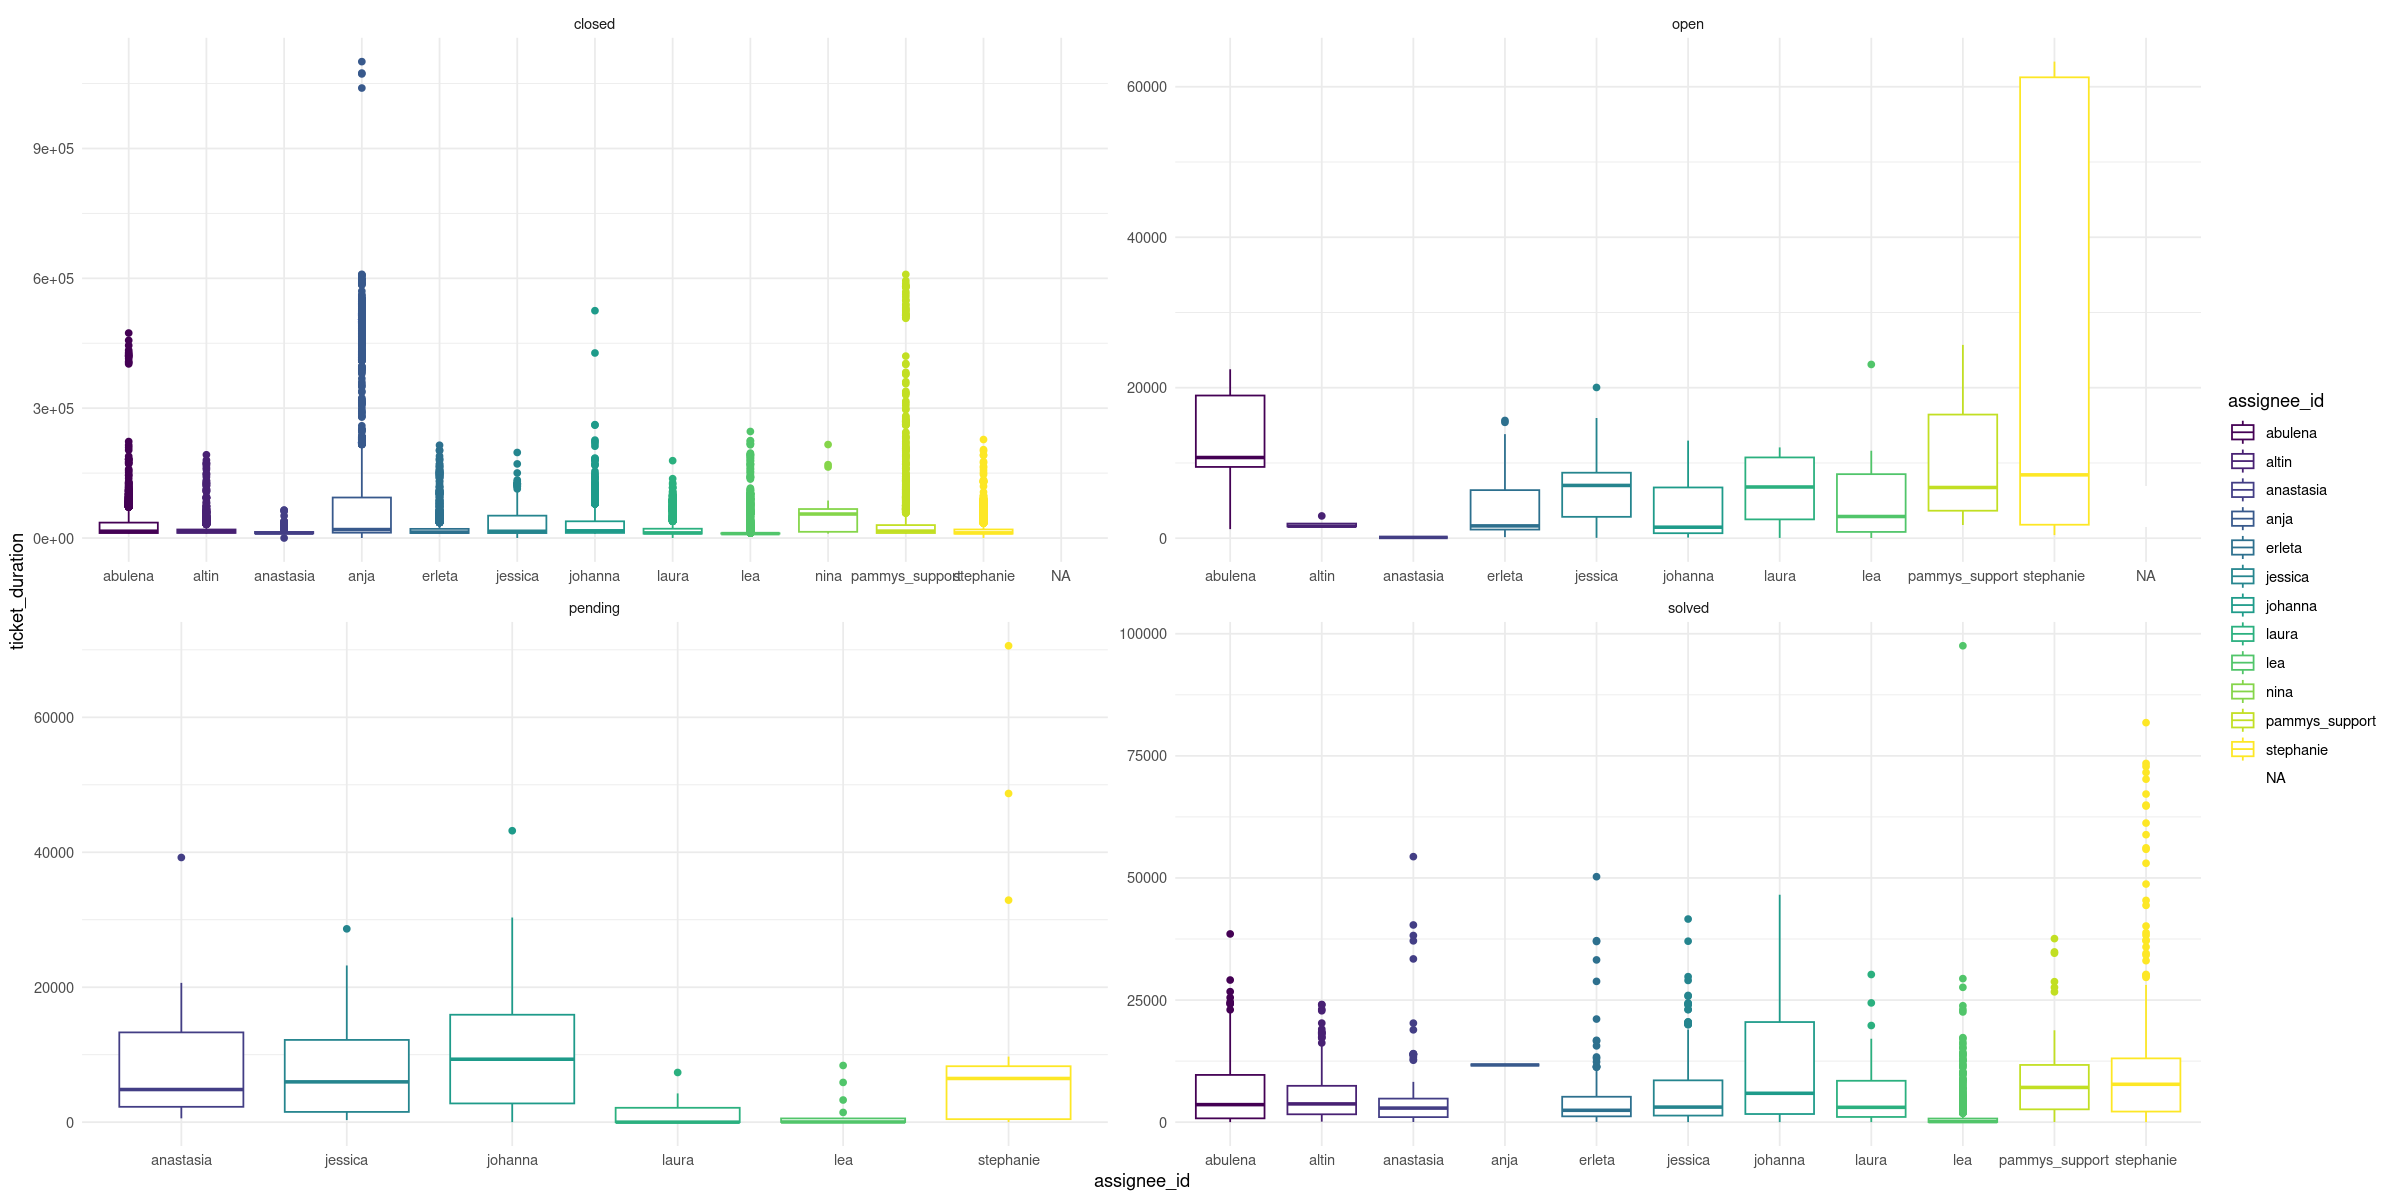

In [11]:
options(repr.plot.width = 20, repr.plot.height = 10)
ggplot(all_tickets_selected |> filter(!is.na(assignee_id) | status != "new")|> select(-collaborator_id, - follower_ids_1) |> distinct(), aes(x = assignee_id, y = ticket_duration, color = assignee_id)) + 
geom_boxplot() + 
facet_wrap(~status, scales = "free") + 
theme_minimal() + 
scale_color_viridis_d()

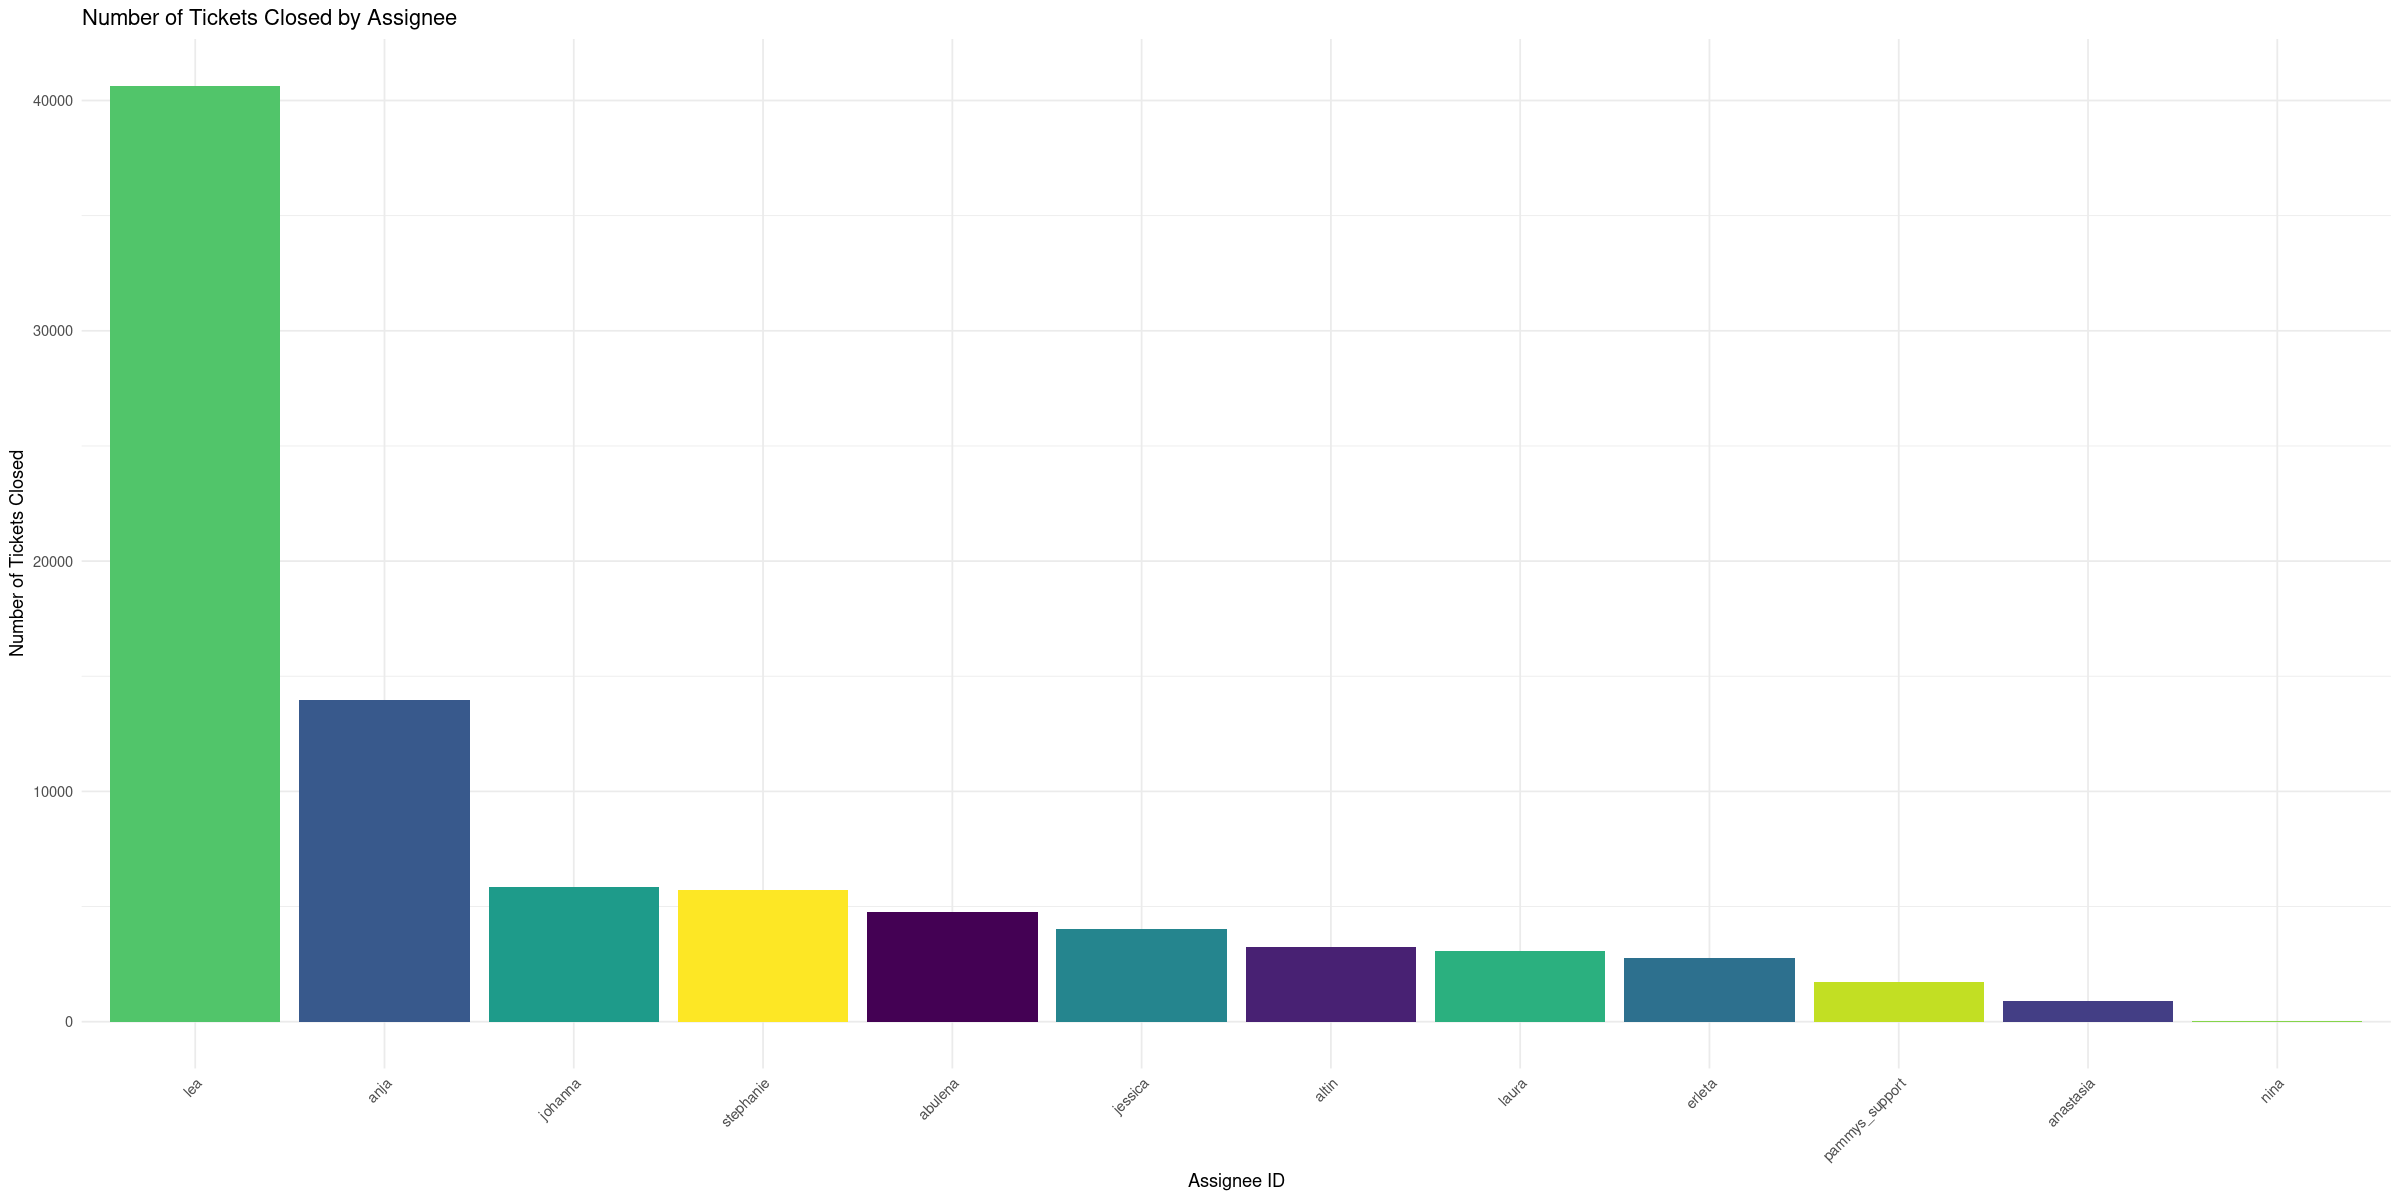

In [12]:
library(ggplot2)

all_tickets_selected |>
  filter(status == "closed", !is.na(assignee_id)) |>
  group_by(assignee_id) |>
  summarise(n_tickets_closed = n()) |>
  ggplot(aes(x = reorder(assignee_id, -n_tickets_closed), y = n_tickets_closed, fill = assignee_id)) +
  geom_col(show.legend = FALSE) +
  labs(
    title = "Number of Tickets Closed by Assignee",
    x = "Assignee ID",
    y = "Number of Tickets Closed"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  scale_fill_viridis_d()